### **CORRELACION**

**Importar librerías**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

**Cargar CSV**

In [2]:
url = "https://raw.githubusercontent.com/MarvinAntillon97/Parcial4_AntillonMarvin_2533222022/refs/heads/main/Archivos/clave_E_correlacion.csv"

df = pd.read_csv(url)

df.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,E-C0001,18,1407,7,92.64,7.98,1,3,17.08,578.39
1,E-C0002,29,742,5,61.63,6.81,3,5,16.22,316.79
2,E-C0003,44,1095,9,71.44,8.47,1,7,15.51,633.41
3,E-C0004,51,1036,5,85.68,7.85,3,6,25.30,464.39
4,E-C0005,29,669,4,55.02,6.25,1,2,23.25,251.46


**Estructura del dataset**

In [3]:
print(df.shape)

print(df.columns)

print(df.info())

(241, 10)
Index(['cliente_id', 'edad', 'ingresos_mensuales', 'frecuencia_compra',
       'ticket_promedio', 'satisfaccion', 'reclamos', 'uso_app',
       'tiempo_respuesta', 'consumo_total'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          241 non-null    object 
 1   edad                241 non-null    int64  
 2   ingresos_mensuales  241 non-null    int64  
 3   frecuencia_compra   241 non-null    int64  
 4   ticket_promedio     240 non-null    float64
 5   satisfaccion        240 non-null    float64
 6   reclamos            241 non-null    int64  
 7   uso_app             241 non-null    int64  
 8   tiempo_respuesta    240 non-null    float64
 9   consumo_total       241 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 19.0+ KB
None


**Nulos o Duplicados**

In [4]:
print(df.isnull().sum())

print(df.duplicated().sum())

cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64
1


**Identificar variables numericas**

In [5]:
variables_numericas = df.select_dtypes(
    include=['int64', 'float64']
)

print(variables_numericas.columns)

Index(['edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio',
       'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta',
       'consumo_total'],
      dtype='object')


**Revisar valores atípicos**

In [6]:
for columna in variables_numericas.columns:

    media = df[columna].mean()
    desviacion = df[columna].std()

    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    atipicos = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print("Variable:", columna)
    print("Cantidad de atípicos:", len(atipicos))
    print("-" * 40)

Variable: edad
Cantidad de atípicos: 11
----------------------------------------
Variable: ingresos_mensuales
Cantidad de atípicos: 9
----------------------------------------
Variable: frecuencia_compra
Cantidad de atípicos: 4
----------------------------------------
Variable: ticket_promedio
Cantidad de atípicos: 8
----------------------------------------
Variable: satisfaccion
Cantidad de atípicos: 8
----------------------------------------
Variable: reclamos
Cantidad de atípicos: 9
----------------------------------------
Variable: uso_app
Cantidad de atípicos: 10
----------------------------------------
Variable: tiempo_respuesta
Cantidad de atípicos: 10
----------------------------------------
Variable: consumo_total
Cantidad de atípicos: 6
----------------------------------------


**Calcular matriz de correlación**

In [7]:
matriz_correlacion = variables_numericas.corr()

print(matriz_correlacion.round(2))

                    edad  ingresos_mensuales  frecuencia_compra  \
edad                1.00               -0.01              -0.04   
ingresos_mensuales -0.01                1.00               0.24   
frecuencia_compra  -0.04                0.24               1.00   
ticket_promedio     0.19                0.60               0.13   
satisfaccion       -0.01                0.06               0.08   
reclamos            0.06                0.02              -0.04   
uso_app            -0.03                0.21               0.49   
tiempo_respuesta   -0.02                0.05              -0.12   
consumo_total       0.03                0.45               0.89   

                    ticket_promedio  satisfaccion  reclamos  uso_app  \
edad                           0.19         -0.01      0.06    -0.03   
ingresos_mensuales             0.60          0.06      0.02     0.21   
frecuencia_compra              0.13          0.08     -0.04     0.49   
ticket_promedio                1.00      

**Crear mapa de calor (Heatmap)**

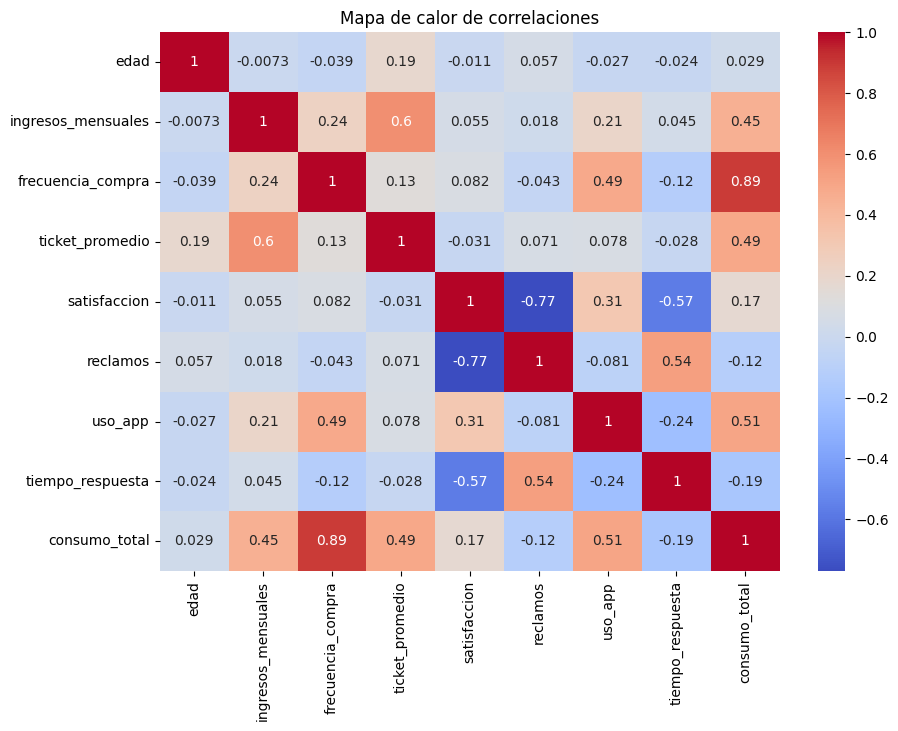

In [8]:
plt.figure(figsize=(10,7))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap='coolwarm'
)

plt.title('Mapa de calor de correlaciones')

plt.show()